In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('../datasets/ottawa_city_scraper.duckdb', read_only=True)

con.execute("SELECT COUNT(*) AS motions, COUNT(DISTINCT motion_moved_by) AS movers FROM motions WHERE motion_moved_by IS NOT NULL").df()

,motions,movers
0,6651,60


In [2]:
con.execute("SELECT * from councillors").df()

,full_name,municipality,first_name,last_name,first_name_initial,title,ward_number,ward_name,telephone,fax,email,active
0,Mark Sutcliffe,ottawa,Mark,Sutcliffe,M. Sutcliffe,Mayor,,,613-580-2496,613-580-2509,mark.sutcliffe@ottawa.ca,True
1,Matthew Luloff,ottawa,Matthew,Luloff,M. Luloff,Councillor and Deputy Mayor,1,Orléans East-Cumberland,613-580-2471,613-580-2511,matt.luloff@ottawa.ca,True
2,Laura Dudas,ottawa,Laura,Dudas,L. Dudas,Councillor,2,Orléans West-Innes,613-580-2472,613-580-2512,laura.dudas@ottawa.ca,True
3,David Hill,ottawa,David,Hill,D. Hill,Councillor,3,Barrhaven West,613-580-2473,613-580-2513,david.hill@ottawa.ca,True
4,Cathy Curry,ottawa,Cathy,Curry,C. Curry,Councillor,4,Kanata North,613-580-2474,613-580-2514,cathy.curry@ottawa.ca,True
5,Clarke Kelly,ottawa,Clarke,Kelly,C. Kelly,Councillor,5,West Carleton-March,613-580-2475,613-580-2515,clarke.kelly@ottawa.ca,True
6,Glen Gower,ottawa,Glen,Gower,G. Gower,Councillor,6,Stittsville,613-580-2476,613-580-2516,glen.gower@ottawa.ca,True
7,Theresa Kavanagh,ottawa,Theresa,Kavanagh,T. Kavanagh,Councillor,7,Bay,613-580-2477,613-580-2517,bayward@ottawa.ca,True
8,Laine Johnson,ottawa,Laine,Johnson,L. Johnson,Councillor,8,College,613-580-2478,613-580-2518,collegeward@ottawa.ca,True
9,Sean Devine,ottawa,Sean,Devine,S. Devine,Councillor,9,Knoxdale-Merivale,613-580-2479,613-580-2519,knoxdalemerivale@ottawa.ca,True


In [26]:
con.execute("SELECT * FROM motions WHERE motion_moved_by = 'A. Hubley' ORDER BY motion_number DESC").df()

,motion_id,item_id,meeting_id,motion_number,motion_moved_by,motion_seconded_by,motion_text,motion_result,for_count,against_count
0,5d4efd922205b5c19fe1a4582f58147c,abebcc06f62262ee0667b05998afde8d,be87d5cd-cc45-476e-95b7-48a46730beae,2026-16-01,A. Hubley,,BE IT RESOLVED THAT the Audit Committee approv...,Carried,0,0
1,00645b8229f9cdc398ec16235259e1ad,6dfecd265acb4ea1d0e523e15fed161c,58e1bbe0-726d-4a01-ac6a-8d2574c86438,2025-61-03,A. Hubley,D. Brown,,Carried,0,0
2,31a736f491e8dd75ecb92b1667553ae5,b430c5be5de0d77a13aeaa76d8b590e2,d946c63d-7222-49dd-b1c9-b252c8366726,2025-58-05,A. Hubley,T. Tierney,WHEREAS the City recognizes the value patios b...,Carried,0,0
3,7b9b03b71e3475edfeafb04a2794b118,b966a437b21fce89be8465a11e5ddb2b,73a8dd97-8cfd-436f-8f65-e987ffa27aae,2025-56-07,A. Hubley,D. Brown,WHEREAS the second draft of the New Zoning By-...,Lost on a tie (12 to 12),12,12
4,04acdb7f7e6a87b6db3ccd05fa64596e,4d4c7fa1568518a504781af170e5e38c,a2a43b92-4508-4614-9281-2cd01de44500,2025-15-02,A. Hubley,,That the Audit Committee recommend that Counci...,Carried,0,0
5,22adbeef04bda0d6c41dbc95b2e519e3,b19242d791682921bf30761861767f23,a2a43b92-4508-4614-9281-2cd01de44500,2025-15-01,A. Hubley,,BE IT RESOLVED THAT the Audit Committee approv...,Carried,0,0
6,ebd52db98fdf904bc0819456bcb74ce8,caeaceb0f641a85b458e92f6fad55480,628aae94-b5d4-4299-9011-d1bf11fa89ae,2025-14-01,A. Hubley,,BE IT RESOLVED THAT the Audit Committee approv...,Carried,0,0
7,1c8c8b4f149c05e63a7f768481042742,32d9c545959492c5612d13534b892a83,24351152-fdb8-4650-b7ea-eab8b34f2942,2025-13-01,A. Hubley,,BE IT RESOLVED THAT the Audit Committee approv...,Carried,0,0
8,090bb94661f9dcddd9f834ba7f4cfdf3,416ceb07e3c126b5bfdc2dd0f41f426c,b4b6d4e1-089f-4e26-987e-b206e0ace965,2025-12-01,A. Hubley,,WHEREAS the report on this item was issued sep...,Carried,0,0
9,a740d0c6f58a6bb7243208f3697997ee,ac090e560e75dc3b8df286b5c8a15c81,f7927e1b-535a-42d1-9583-6e1fdfacddba,2024-40-09,A. Hubley,S. Devine,THAT City Council refer the staff report title...,Carried,0,0


In [4]:
con.execute("SELECT c.full_name, COUNT(*) AS motions_moved FROM motions m JOIN councillors c ON m.motion_moved_by LIKE c.first_name_initial WHERE m.motion_moved_by IS NOT NULL GROUP BY c.full_name ORDER BY motions_moved DESC;").df()

,full_name,motions_moved
0,Glen Gower,194
1,Stéphanie Plante,134
2,Shawn Menard,132
3,Catherine Kitts,127
4,David Brown,126
5,Riley Brockington,107
6,Ariel Troster,107
7,Jeff Leiper,101
8,Clarke Kelly,92
9,Laura Dudas,86


In [5]:
motions_moved_by_councillors = con.execute("SELECT c.full_name, COUNT(*) AS motions_moved FROM motions m JOIN councillors c ON m.motion_moved_by LIKE c.first_name_initial WHERE m.motion_moved_by IS NOT NULL GROUP BY c.full_name ORDER BY motions_moved DESC;").df()
print(motions_moved_by_councillors['full_name'].size)
print(motions_moved_by_councillors['motions_moved'].sum())

26
1950


In [13]:
# Check what motion_moved_by actually looks like
con.execute("SELECT DISTINCT motion_moved_by FROM motions WHERE motion_moved_by IS NOT NULL LIMIT 20").df()
# Check what the join key looks like from councillors
con.execute("SELECT full_name, first_name_initial, last_name, first_name_initial || ' ' || last_name AS join_key FROM councillors LIMIT 20").df()
# See if any join matches at all
con.execute("""
    SELECT DISTINCT m.motion_moved_by, c.full_name, c.first_name_initial AS join_key
    FROM motions m, councillors c
    WHERE m.motion_moved_by IS NOT NULL
    LIMIT 20
""").df()


,motion_moved_by,full_name,join_key
0,M. Luloff,Mark Sutcliffe,M. Sutcliffe
1,,Matthew Luloff,M. Luloff
2,Member Brent Bauer,Matthew Luloff,M. Luloff
3,H. Saikali,Matthew Luloff,M. Luloff
4,G. Gower,Laura Dudas,L. Dudas
5,S. Plante,Laura Dudas,L. Dudas
6,Member Brent Bauer,Laura Dudas,L. Dudas
7,S. Devine,Laura Dudas,L. Dudas
8,Phillip Turcotte,Laura Dudas,L. Dudas
9,M. Luloff,Laura Dudas,L. Dudas


In [7]:
# Check how many votes match councillors.full_name
con.execute("""
    SELECT COUNT(DISTINCT v.councillor_name) AS matched_voters
    FROM votes v
    JOIN councillors c ON v.councillor_name = c.full_name
""").df()
# Check how many votes match councillors.full_name
con.execute("""
    SELECT COUNT(DISTINCT v.councillor_name) AS matched_voters
    FROM votes v
    JOIN councillors c ON v.councillor_name = c.full_name
""").df()


,matched_voters
0,0


In [8]:
con.execute("""
    SELECT COUNT(*) AS vote_records
    FROM votes v
    JOIN motions m ON v.motion_id = m.motion_id
    WHERE m.motion_moved_by = 'M. Luloff'
""").df()


,vote_records
0,0


In [9]:
# Look at the actual motion results and vote counts for Luloff's motions
con.execute("""
    SELECT motion_result, for_count, against_count, COUNT(*) AS n
    FROM motions m
    JOIN councillors c ON m.motion_moved_by LIKE c.first_name_initial
    WHERE c.full_name = 'Matthew Luloff'
    GROUP BY motion_result, for_count, against_count
    ORDER BY n DESC
""").df()


,motion_result,for_count,against_count,n
0,Carried,0,0,32
1,,0,0,5
2,Carried (12 to 0),0,0,1


In [10]:
# Look at the actual motion results and vote counts for Luloff's motions
con.execute("""
    SELECT motion_result, for_count, against_count, COUNT(*) AS n
    FROM motions m
    JOIN councillors c ON m.motion_moved_by LIKE c.first_name_initial
    WHERE c.full_name = 'Mark Sutcliffe'
    GROUP BY motion_result, for_count, against_count
    ORDER BY n DESC
""").df()


,motion_result,for_count,against_count,n
0,Carried,0,0,7
1,,0,0,2


In [11]:
con.execute("""
    SELECT
        m.motion_id,
        m.motion_moved_by,
        c.full_name AS mover_full_name,
        v.vote,
        m.motion_result,
        m.motion_text
    FROM motions m
    JOIN councillors c ON m.motion_moved_by LIKE c.first_name_initial
    JOIN votes v ON m.motion_id = v.motion_id
              AND v.councillor_name LIKE c.first_name_initial
    WHERE v.vote = 'against'
      AND c.active = TRUE
    ORDER BY c.full_name
""").df()


,motion_id,motion_moved_by,mover_full_name,vote,motion_result,motion_text
0,aa69f5890357eb0a820444e910c1129a,C. Kitts,Catherine Kitts,against,Carried (9 to 2),That the Transportation Committee recommend th...
1,0f1d857bd04c8aab89d7bc9626fe1763,G. Gower,Glen Gower,against,Lost (2 to 13),on behalf of Councillor Menard\nWHEREAS the Ri...
2,b0ccf5111fb9c845164e8076c459c138,L. Johnson,Laine Johnson,against,Lost (3 to 8),WHEREAS the recommendation of Kitchissippi Par...
3,84081d798508a81af23576f567044333,S. Devine,Sean Devine,against,Carried (21 to 4),BE IT RESOLVED that Council approve the recomm...


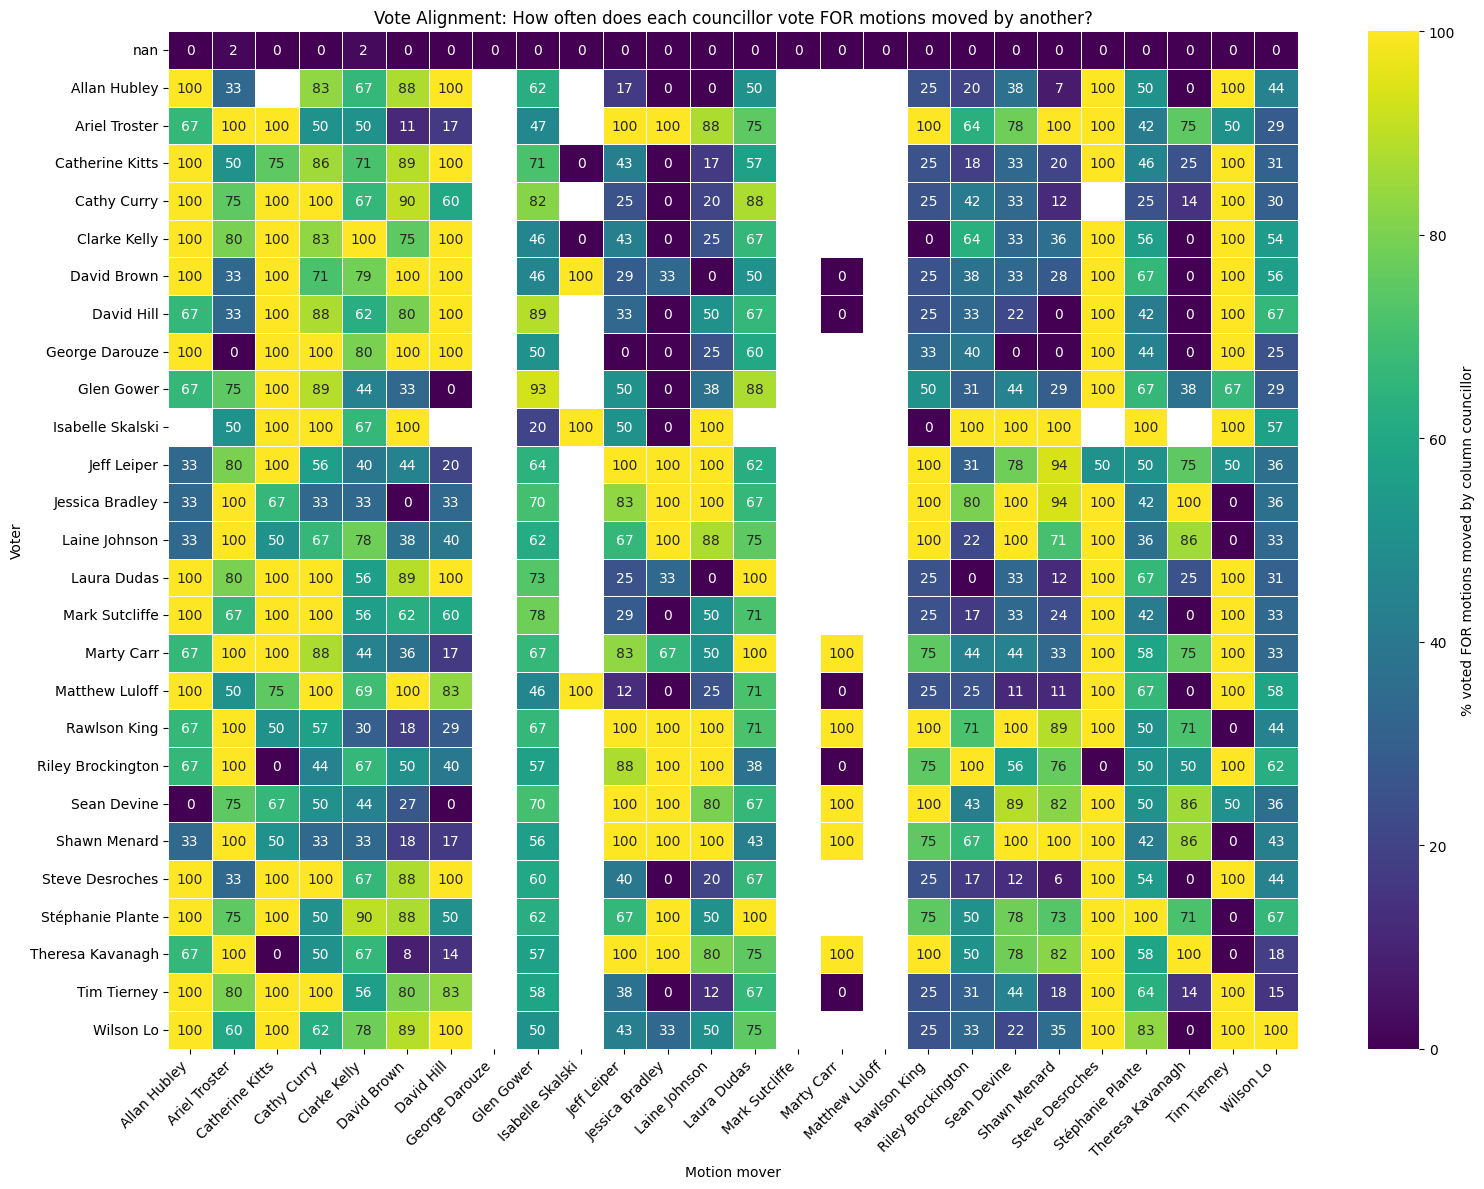

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

alignment_df = con.execute("""
    WITH valid_motions AS (
        SELECT m.motion_id, c.full_name AS mover
        FROM motions m
        JOIN councillors c
            ON m.motion_moved_by = c.first_name_initial
        WHERE m.motion_moved_by IS NOT NULL
    ),
    motion_votes AS (
        SELECT
            vm.mover,
            vc.full_name AS voter,
            v.vote
        FROM valid_motions vm
        LEFT JOIN votes v ON vm.motion_id = v.motion_id
        LEFT JOIN councillors vc ON v.councillor_name LIKE vc.first_name_initial
    )
    SELECT
        mover,
        voter,
        COUNT(*) FILTER (WHERE vote = 'for')         AS voted_for,
        COUNT(*)                                      AS total_votes,
        ROUND(
            100.0 * COUNT(*) FILTER (WHERE vote = 'for') / COUNT(*), 1
        ) AS alignment_pct
    FROM motion_votes
    GROUP BY mover, voter
    ORDER BY mover, alignment_pct DESC
""").df()


alignment_df.head(20)
matrix = alignment_df.pivot(index="voter", columns="mover", values="alignment_pct")

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".0f",
    cmap="viridis",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% voted FOR motions moved by column councillor"},
)
ax.set_title("Vote Alignment: How often does each councillor vote FOR motions moved by another?")
ax.set_xlabel("Motion mover")
ax.set_ylabel("Voter")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
fig.savefig('voting_alignment.png')
